<a href="https://colab.research.google.com/github/philippenchev98/mortality-data-analysis/blob/main/Actuarial_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

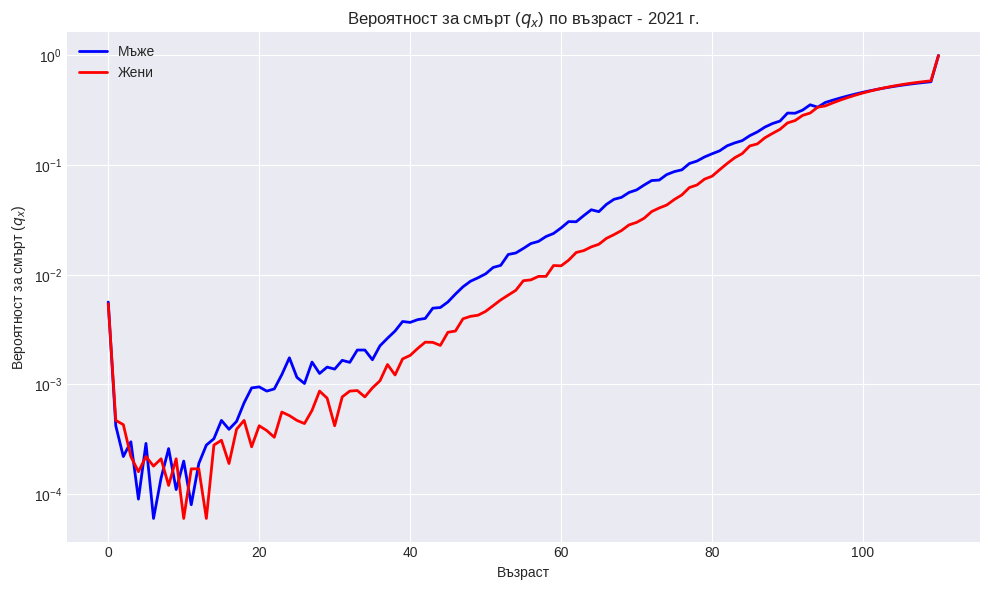

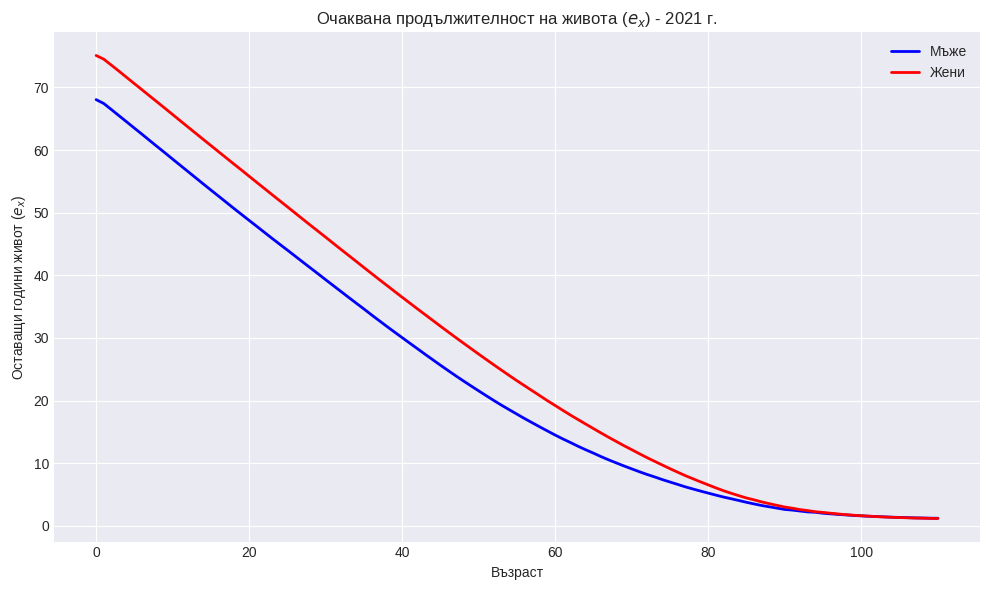

Параметри: Възраст: 30, Срок: 10 г., Сума: 100000 лв., Лихва: 3.0%
Възраст 30: P(смърт) = 0.00138 | Дисконт = 0.9709 | Риск за годината = 134.22 лв.
Възраст 31: P(смърт) = 0.00166 | Дисконт = 0.9426 | Риск за годината = 156.37 лв.
Възраст 32: P(смърт) = 0.00159 | Дисконт = 0.9151 | Риск за годината = 145.26 лв.
Възраст 33: P(смърт) = 0.00205 | Дисконт = 0.8885 | Риск за годината = 181.97 лв.
Възраст 34: P(смърт) = 0.00205 | Дисконт = 0.8626 | Риск за годината = 176.67 лв.
Възраст 35: P(смърт) = 0.00167 | Дисконт = 0.8375 | Риск за годината = 139.79 лв.
Възраст 36: P(смърт) = 0.00223 | Дисконт = 0.8131 | Риск за годината = 181.51 лв.
Възраст 37: P(смърт) = 0.00260 | Дисконт = 0.7894 | Риск за годината = 205.33 лв.
Възраст 38: P(смърт) = 0.00302 | Дисконт = 0.7664 | Риск за годината = 231.53 лв.
Възраст 39: P(смърт) = 0.00368 | Дисконт = 0.7441 | Риск за годината = 273.55 лв.
Обща Нетна Еднократна Премия (NSP): 1826.19 лв.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#Зареждане на данните от Excel файловете
df_males = pd.read_excel(r"https://github.com/philippenchev98/mortality-data-analysis/raw/refs/heads/main/Life%20males.xlsx")
df_females = pd.read_excel(r"https://github.com/philippenchev98/mortality-data-analysis/raw/refs/heads/main/Life%20females.xlsx")

#Настройка на стила на графиките
plt.style.use('seaborn-v0_8-darkgrid')

#Графика 1: Вероятност за смърт (qx)
plt.figure(figsize=(10, 6))
plt.plot(df_males['Age'], df_males['qx'], label='Мъже', color='blue', linewidth=2)
plt.plot(df_females['Age'], df_females['qx'], label='Жени', color='red', linewidth=2)

#Използваме логаритмична скала, за да видим детайлите при младите възрасти
plt.yscale('log')
plt.title('Вероятност за смърт ($q_x$) по възраст - 2021 г.')
plt.xlabel('Възраст')
plt.ylabel('Вероятност за смърт ($q_x$)')
plt.legend()
plt.tight_layout()
plt.show()

#Графика 2: Очаквана продължителност на живота (ex)
plt.figure(figsize=(10, 6))
plt.plot(df_males['Age'], df_males['ex'], label='Мъже', color='blue', linewidth=2)
plt.plot(df_females['Age'], df_females['ex'], label='Жени', color='red', linewidth=2)

plt.title('Очаквана продължителност на живота ($e_x$) - 2021 г.')
plt.xlabel('Възраст')
plt.ylabel('Оставащи години живот ($e_x$)')
plt.legend()
plt.tight_layout()
plt.show()


def calculate_term_life_nsp(df, age, term, sum_assured, interest_rate):
    """Изчислява Нетната Еднократна Премия (NSP) за срочна застраховка живот."""
    nsp = 0.0
    v = 1 / (1 + interest_rate)  #Дисконтов фактор

    #Взимаме броя живи хора на началната възраст (l_x)
    l_x = df.loc[df['Age'] == age, 'lx'].values[0]

    print(f"Параметри: Възраст: {age}, Срок: {term} г., Сума: {sum_assured} лв., Лихва: {interest_rate * 100}%")

    #Цикъл през всяка година от срока на полицата
    for t in range(term):
        current_age = age + t

        #Брой починали на текущата разглеждана възраст
        d_x_t = df.loc[df['Age'] == current_age, 'dx'].values[0]

        #Вероятност 30-годишният да почине точно в тази конкретна година
        prob_death = d_x_t / l_x

        #Дисконтираме с t+1 години (приемаме плащане в края на годината на смъртта)
        discount = v ** (t + 1)

        #Очаквана настояща стойност на риска за тази година
        epv_year = sum_assured * prob_death * discount

        #Добавяме към общата сума
        nsp += epv_year

        print(
            f"Възраст {current_age}: P(смърт) = {prob_death:.5f} | Дисконт = {discount:.4f} | Риск за годината = {epv_year:.2f} лв.")

    return nsp


#Тестваме функцията

premium = calculate_term_life_nsp(df_males, age=30, term=10, sum_assured=100000, interest_rate=0.03)


print(f"Обща Нетна Еднократна Премия (NSP): {premium:.2f} лв.")